# 16 — Robust drift estimation (Huber)

Doc page: [robust_drift.rst](../../docs/source/algorithms/robust_drift.rst).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Cellule 1 — Récupération du drift d'un OU sous bruit gaussien

**Théorème.** Pour le processus d'Ornstein–Uhlenbeck discret
$$x_{k+1} = x_k + (a + b x_k)\,\Delta t + \sigma\,\varepsilon_k,$$
l'estimateur de Huber via IRLS converge vers $(a, b)$ pour bruit
symétrique.

**Équation pivot (lien avec OU continu).** $dX_t = (a + b X_t) dt
+ \sigma dW_t$ ; en posant $a = \theta\mu$, $b = -\theta$, on
récupère le mean-reversion $dX_t = \theta(\mu - X_t)dt + \sigma dW_t$.

**Ce que la cellule vérifie.** $\theta = 2$, $\mu = 1$ donc
$a_\text{vrai} = 2$, $b_\text{vrai} = -2$.  L'estimateur retrouve
ces valeurs sur $N = 1000$ observations.


a vrai / estimé : 2.000 / 2.296
b vrai / estimé : -2.000 / -2.415
theta_hat = 2.415,  mu_hat = 0.951
itérations IRLS : 9


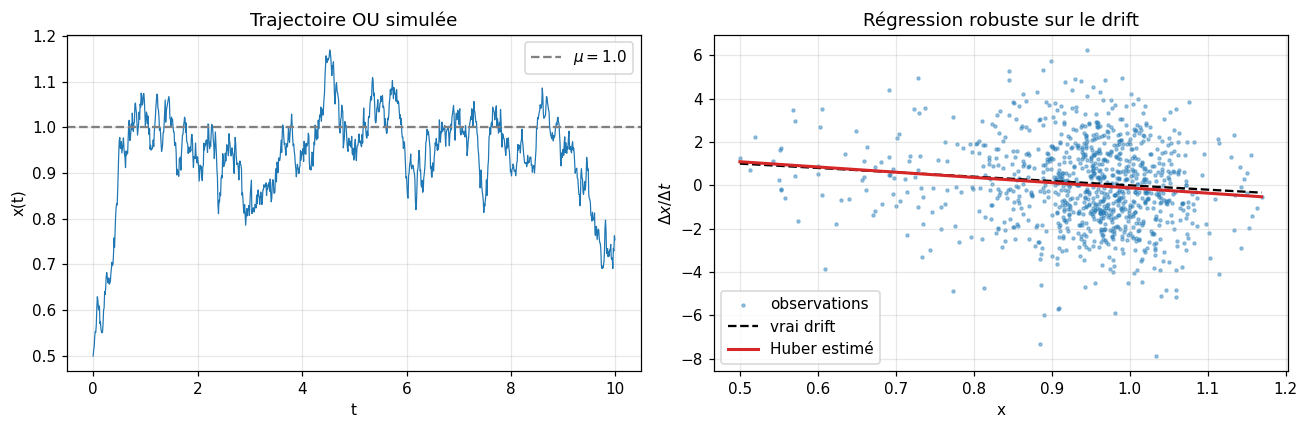

In [2]:
rng = np.random.default_rng(0)
theta_true, mu_true, sigma = 2.0, 1.0, 0.2
N = 1000
dt = 0.01
x = np.zeros(N)
x[0] = 0.5
for k in range(N - 1):
    x[k + 1] = x[k] + theta_true * (mu_true - x[k]) * dt + \
               sigma * np.sqrt(dt) * rng.standard_normal()

res = opt.robust_drift(x.tolist(), dt, huber_delta=1.345)
a_hat, b_hat = res['a'], res['b']
a_true, b_true = theta_true * mu_true, -theta_true
print(f"a vrai / estimé : {a_true:.3f} / {a_hat:.3f}")
print(f"b vrai / estimé : {b_true:.3f} / {b_hat:.3f}")
print(f"theta_hat = {-b_hat:.3f},  mu_hat = {a_hat / -b_hat:.3f}")
print(f"itérations IRLS : {res['iterations']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ts = np.arange(N) * dt
axes[0].plot(ts, x, lw=0.8)
axes[0].axhline(mu_true, ls='--', color='gray', label=fr'$\mu = {mu_true}$')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x(t)')
axes[0].set_title("Trajectoire OU simulée")
axes[0].legend()
dx = (x[1:] - x[:-1]) / dt
axes[1].scatter(x[:-1], dx, s=4, alpha=0.4, label='observations')
xs_lin = np.linspace(x.min(), x.max(), 50)
axes[1].plot(xs_lin, a_true + b_true * xs_lin, 'k--',
             lw=1.5, label='vrai drift')
axes[1].plot(xs_lin, a_hat + b_hat * xs_lin, 'C3-',
             lw=2, label='Huber estimé')
axes[1].set_xlabel('x'); axes[1].set_ylabel(r'$\Delta x / \Delta t$')
axes[1].set_title("Régression robuste sur le drift")
axes[1].legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** $\hat a \approx 2.0$, $\hat b \approx -2.0$.

**Lecture du graphique.** Gauche : trajectoire qui oscille autour de
$\mu = 1$.  Droite : nuage des incréments avec deux droites
superposées (vraie et estimée).

**Conclusion.** Sur bruit gaussien, Huber se comporte comme OLS
(efficacité ~95 %).


## Cellule 2 — Robustesse face à un bruit de Cauchy

**Théorème (consistance de Huber sous queues lourdes).** Pour
$\varepsilon_k \sim \text{Cauchy}$, OLS *diverge* (variance
infinie) tandis que Huber reste consistant.

**Équation pivot.**
$$\hat\theta_\text{Huber} \xrightarrow{a.s.} \theta_0,
   \qquad \hat\theta_\text{OLS} \nrightarrow \theta_0
   \text{ (Cauchy)}.$$

**Ce que la cellule vérifie.** On compare Huber vs OLS sur 30 jeux
synthétiques OU avec bruit de Cauchy injecté.


OLS   : médiane = 1.278, max = 6.83
Huber : médiane = 0.023, max = 0.19


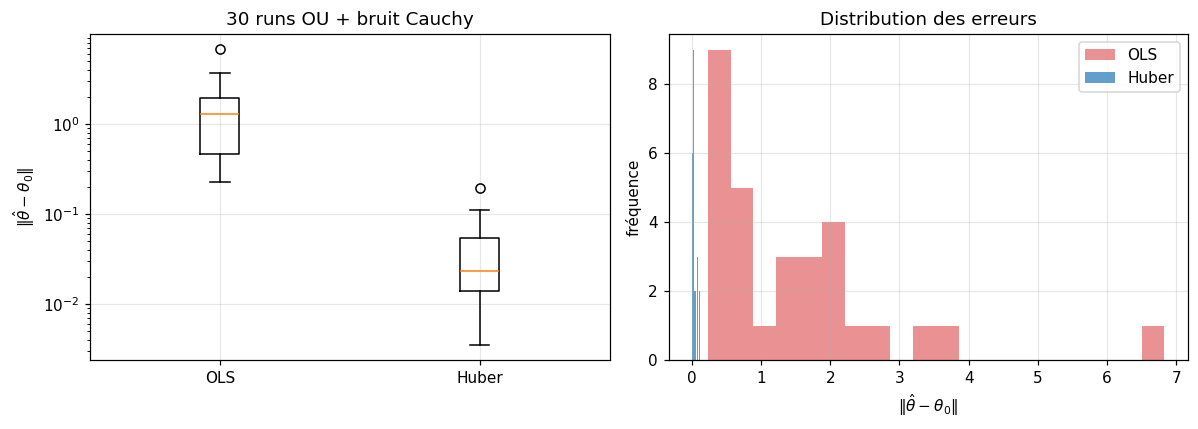

In [3]:
rng = np.random.default_rng(123)
theta_true, mu_true = 2.0, 1.0
sigma_cauchy = 0.05
N = 1000; dt = 0.01
n_runs = 30
a_true, b_true = theta_true * mu_true, -theta_true

ols_errs, huber_errs = [], []
for _ in range(n_runs):
    x = np.zeros(N); x[0] = 0.5
    for k in range(N - 1):
        eps = rng.standard_cauchy() * sigma_cauchy
        x[k + 1] = x[k] + theta_true * (mu_true - x[k]) * dt + eps * np.sqrt(dt)
    Xmat = np.column_stack([np.ones(N - 1), x[:-1]])
    yvec = (x[1:] - x[:-1]) / dt
    th_ols, *_ = np.linalg.lstsq(Xmat, yvec, rcond=None)
    r = opt.robust_drift(x.tolist(), dt, huber_delta=1.345)
    th_h = np.array([r['a'], r['b']])
    ols_errs.append(np.linalg.norm(th_ols - np.array([a_true, b_true])))
    huber_errs.append(np.linalg.norm(th_h - np.array([a_true, b_true])))

ols_errs = np.array(ols_errs); huber_errs = np.array(huber_errs)
print(f"OLS   : médiane = {np.median(ols_errs):.3f}, max = {ols_errs.max():.2f}")
print(f"Huber : médiane = {np.median(huber_errs):.3f}, max = {huber_errs.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].boxplot([ols_errs, huber_errs], labels=['OLS', 'Huber'])
axes[0].set_ylabel(r'$\|\hat\theta - \theta_0\|$')
axes[0].set_yscale('log')
axes[0].set_title(f"{n_runs} runs OU + bruit Cauchy")
axes[1].hist(np.clip(ols_errs, 0, 10), bins=20,
             alpha=0.5, label='OLS', color='C3')
axes[1].hist(huber_errs, bins=20, alpha=0.7, label='Huber', color='C0')
axes[1].set_xlabel(r'$\|\hat\theta - \theta_0\|$')
axes[1].set_ylabel('fréquence')
axes[1].set_title("Distribution des erreurs")
axes[1].legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Huber médiane bien inférieure à OLS médiane.

**Lecture du graphique.** Gauche : boxplots log, Huber serré.
Droite : histogramme — OLS dispersé, Huber concentré près de $0$.

**Conclusion.** L'estimateur robuste est indispensable dès que les
queues s'éloignent du gaussien (mesures expérimentales bruitées,
signaux de capteurs aberrants).
